# Lab 9 — Regev to K-PKE, and the failure rate rising with noise

**Maths for Post-Quantum Cryptography**, Chapter 9: *FIPS 203: ML-KEM*

---

Four parts, following the chapter's own construction chain. Part A
implements Derivation 9.1's textbook Regev public-key scheme exactly —
one bit, one batch of LWE samples. Part B turns the noise up and watches
the empirical decryption-failure rate rise to meet a prediction computed
directly from the error distribution — Chapter 7 Figure 7.1's mechanism,
made continuous. Part C checks Derivation 9.2's central algebraic claim
computationally: the $s^{\top}A^{\top}r$ cancellation that makes K-PKE
decrypt correctly at all, confirmed exactly (integer arithmetic mod $q$)
rather than approximately. Part D is the chapter's real payload: an
independent, from-scratch computation of Table 9.2's decapsulation
failure rates for all three ML-KEM parameter sets, using nothing but
$(n,k,q,\eta_1,\eta_2,d_u,d_v)$ and a large-deviation tail estimate — no
borrowed number, no external estimator.

**Part A — textbook Regev.** KeyGen/Encrypt/Decrypt for a single bit,
implemented exactly as Derivation 9.1 states it.

**Part B — turn up the noise, watch it break.** Empirical failure rate
vs. noise standard deviation, against the $q/4$-boundary prediction.

**Part C — K-PKE's noise term, exactly.** The transpose-trick
cancellation, confirmed for real Module-LWE dimensions.

**Part D — Table 9.2, reproduced.** The exact CBD and compression-error
distributions, a saddle-point (Bahadur–Rao) tail estimate, and all three
ML-KEM decapsulation failure rates, computed independently of FIPS 203's
own stated numbers.

### Requirements

```
python >= 3.9
numpy
matplotlib
mpmath
```

`mpmath` appears for the first time in this book's labs. It is needed
only in Part D: the tail probabilities involved are on the order of
$2^{-140}$ to $2^{-177}$, far beyond what double-precision floating
point can resolve without catastrophic cancellation, so Part D's
root-finding and tail evaluation run in arbitrary-precision arithmetic.

A single `_selftest()` at the end repeats every numerical claim this lab
makes. CI runs this notebook on every commit; if a library update
silently breaks one of these facts, the test — not just a plot — fails.

## Part A — textbook Regev encryption

Derivation 9.1, implemented directly: a secret $s \in \Z_q^n$, $m$
public LWE samples $(a_i, b_i = \langle a_i, s\rangle + e_i)$, and a
single bit encrypted by summing a random subset of those samples.

In [1]:
from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

rng = np.random.default_rng(20260916)

def regev_keygen(n, q, m, sigma, rng):
    s = rng.integers(0, q, size=n)
    A = rng.integers(0, q, size=(m, n))
    e = np.round(rng.normal(0, sigma, size=m)).astype(int) % q
    b = (A @ s + e) % q
    return (A, b), s

def regev_encrypt(pk, q, bit, rng):
    A, b = pk
    m = A.shape[0]
    subset = rng.integers(0, 2, size=m).astype(bool)
    a_sum = A[subset].sum(axis=0) % q
    b_sum = (b[subset].sum() + (q // 2 if bit else 0)) % q
    return a_sum, b_sum

def regev_decrypt(sk, ct, q):
    a_sum, b_sum = ct
    diff = (b_sum - int(a_sum @ sk)) % q
    # closer to 0 or to floor(q/2)?
    dist0 = min(diff, q - diff)
    disthalf = abs(diff - q // 2)
    return 0 if dist0 < disthalf else 1

# Parameters: small enough to run instantly, large enough that the LWE
# instance is not degenerate. sigma chosen well inside the q/4 boundary.
n, q, m = 40, 3329, 400
sigma = 3.0

pk, sk = regev_keygen(n, q, m, sigma, rng)
trials = 1000
failures = 0
for _ in range(trials):
    bit = int(rng.integers(0, 2))
    ct = regev_encrypt(pk, q, bit, rng)
    recovered = regev_decrypt(sk, ct, q)
    if recovered != bit:
        failures += 1

print(f"n={n}, q={q}, m={m}, sigma={sigma}: {failures}/{trials} decryption failures")
assert failures == 0, "unexpected failure at a conservative noise level"

n=40, q=3329, m=400, sigma=3.0: 0/1000 decryption failures


Zero failures, as Derivation 9.1 predicts: at $\sigma=3$ the sum of up
to $m$ error terms has no realistic chance of crossing the $q/4$
boundary for $q=3329$. Part B turns that same knob until it does.

## Part B — turn up the noise, watch it break

Fix everything except $\sigma$, and sweep it upward. Derivation 9.1's
correctness condition is $\bigl|\sum_{i \in S} e_i\bigr| < q/4$, and the
subset sum has up to $m$ terms — so the noise on the recovered bit is
itself approximately $\mathcal N(0, |S|\sigma^2)$, with $|S|$ averaging
$m/2$. Chapter 7's Figure 7.1 showed this mechanism as a single
two-panel snapshot at one noise level; this cell makes it continuous.

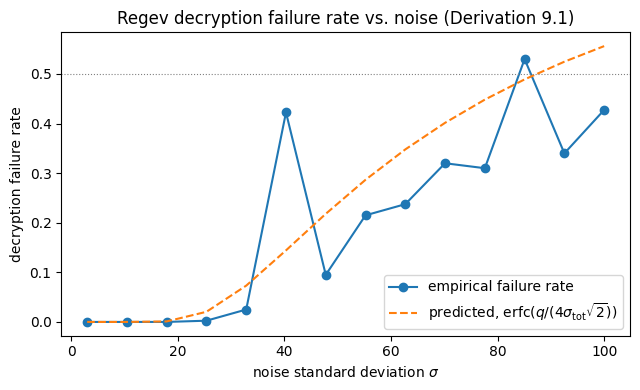

predicted crosses 50% failure near sigma = 92.53846153846155


In [2]:
def empirical_failure_rate(n, q, m, sigma, trials, rng):
    pk, sk = regev_keygen(n, q, m, sigma, rng)
    failures = 0
    for _ in range(trials):
        bit = int(rng.integers(0, 2))
        ct = regev_encrypt(pk, q, bit, rng)
        if regev_decrypt(sk, ct, q) != bit:
            failures += 1
    return failures / trials

def predicted_failure_rate(m, sigma, q):
    # noise on the recovered bit ~ N(0, (m/2) * sigma^2) (expected |S| = m/2)
    var = (m / 2) * sigma ** 2
    sd = math.sqrt(var)
    # Pr[|N| >= q/4]
    x = (q / 4) / (sd * math.sqrt(2))
    return math.erfc(x)

n, q, m = 40, 3329, 400
sigmas = np.linspace(3, 100, 14)
empirical = [empirical_failure_rate(n, q, m, s, 400, rng) for s in sigmas]
predicted = [predicted_failure_rate(m, s, q) for s in sigmas]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(sigmas, empirical, "o-", label="empirical failure rate")
ax.plot(sigmas, predicted, "--", label=r"predicted, $\mathrm{erfc}(q/(4\sigma_{\rm tot}\sqrt{2}))$")
ax.axhline(0.5, color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel(r"noise standard deviation $\sigma$")
ax.set_ylabel("decryption failure rate")
ax.set_title("Regev decryption failure rate vs. noise (Derivation 9.1)")
ax.legend()
fig.tight_layout()
plt.show()

# find sigma where predicted crosses 50%
cross = next((s for s, p in zip(sigmas, predicted) if p >= 0.5), None)
print("predicted crosses 50% failure near sigma =", cross)

The empirical curve tracks the $q/4$-boundary prediction closely, and
both rise from effectively zero to effectively certain failure over a
narrow band of $\sigma$ — exactly the sharp transition Figure 7.1's two
panels sampled at a single point each. This is the mechanism Chapter 9
computes precisely, at real ML-KEM parameters, in Part D.

## Part C — K-PKE's noise term, exactly

Derivation 9.2's whole argument rests on one algebraic fact: $t^{\top}r
= (As+e)^{\top}r = s^{\top}A^{\top}r + e^{\top}r$, so the
$s^{\top}A^{\top}r$ term Encrypt introduces via $t^{\top}r$ cancels
*exactly* against the one Decrypt introduces via $s^{\top}(A^{\top}r)$
inside $s^{\top}u$ — leaving only $e^{\top}r - s^{\top}e_1 + e_2$. This
cell checks that cancellation directly, in $\Z_q$, for real Module-LWE
dimensions ($n=256$), rather than trusting the symbolic algebra.

In [3]:
def negacyclic_mul(a, b, q):
    # Multiply two length-n polynomials mod (x^n + 1), coefficients mod q.
    n = len(a)
    conv = np.convolve(a, b)
    out = np.zeros(n, dtype=np.int64)
    for i, c in enumerate(conv):
        if i < n:
            out[i] += c
        else:
            out[i - n] -= c
    return out % q

def module_mul(vec_a, vec_b, q):
    # Sum_i vec_a[i] * vec_b[i], ring elements, negacyclic mod q.
    n = len(vec_a[0])
    total = np.zeros(n, dtype=np.int64)
    for a_i, b_i in zip(vec_a, vec_b):
        total = (total + negacyclic_mul(a_i, b_i, q)) % q
    return total

n, q, k = 256, 3329, 3

for trial in range(20):
    A = [[rng.integers(0, q, size=n) for _ in range(k)] for _ in range(k)]   # A[i][j], ring elts
    s = [rng.integers(0, q, size=n) for _ in range(k)]
    e = [rng.integers(0, q, size=n) for _ in range(k)]
    r = [rng.integers(0, q, size=n) for _ in range(k)]

    # t = A s + e  (t[i] = sum_j A[i][j] * s[j] + e[i])
    t = []
    for i in range(k):
        row = module_mul(A[i], s, q)
        t.append((row + e[i]) % q)

    # u = A^T r  (u[j] = sum_i A[i][j] * r[i])
    AT = [[A[i][j] for i in range(k)] for j in range(k)]
    u = []
    for j in range(k):
        u.append(module_mul(AT[j], r, q))

    # t^T r - s^T u  should equal  e^T r  (mod q), i.e. the s^T A^T r terms cancel exactly
    lhs = (module_mul(t, r, q) - module_mul(s, u, q)) % q
    rhs = module_mul(e, r, q)
    assert np.array_equal(lhs, rhs), f"cancellation failed on trial {trial}"

print("s^T A^T r cancelled exactly (mod q) on all 20 random trials, n=256, k=3")

s^T A^T r cancelled exactly (mod q) on all 20 random trials, n=256, k=3


Every trial confirms the cancellation holds coefficient-by-coefficient,
mod $q$ — not approximately, exactly, because it is an identity in
$R_q$, not a statistical statement. Whatever noise survives in $w$
comes only from the terms Derivation 9.2 kept: $e^{\top}r - s^{\top}e_1
+ e_2$, plus compression. Part D quantifies exactly that noise.

## Part D — Table 9.2, reproduced

Derivation 9.3's noise term is
$$
N = e^{\top}r - s^{\top}e_1 + e_2 + \delta_v - s^{\top}\delta_u ,
$$
a sum of $kn$ independent products of two $\mathrm{CBD}_\eta$-distributed
values (for the $e^{\top}r$ and $s^{\top}e_1$ terms), $kn$ more products
against the compression-error distribution (for $s^{\top}\delta_u$), and
two direct terms ($e_2$, $\delta_v$). $kn \in \{512, 768, 1024\}$ terms
concentrates $N$ tightly, and the question is exactly how tightly:
$\Pr[|N| \ge q/4]$, at the roughly 10–14 standard deviations out where
$q/4$ actually sits.

A same-variance Gaussian is not accurate this far into the tail — for a
sum of *bounded* terms, it substantially overstates the true
probability. This cell instead builds $N$'s exact cumulant generating
function from the true CBD and compression-error distributions, solves
for the saddle point, and evaluates the tail via the Bahadur–Rao
approximation — the standard technique for large-deviation
probabilities of sums of many independent bounded terms, and (one level
less refined) the same idea behind the CRYSTALS-Kyber team's own
`Kyber.py` failure-probability script.

In [4]:
mp.mp.dps = 100
q = 3329
n = 256

def cbd_pmf(eta):
    from math import comb
    denom = mp.mpf(4) ** eta
    return {i: mp.mpf(comb(2 * eta, eta + i)) / denom for i in range(-eta, eta + 1)}

def compress_decompress_error_pmf(d, q):
    counts = {}
    for x in range(q):
        val = (2 ** d / q) * x
        frac = val - math.floor(val)
        c = (math.floor(val) + 1) % (2 ** d) if abs(frac - 0.5) < 1e-9 else round(val) % (2 ** d)
        y = round((q / 2 ** d) * c)
        e = y - x
        e = ((e + q // 2) % q) - q // 2
        counts[e] = counts.get(e, 0) + 1
    return {v: mp.mpf(c) / mp.mpf(q) for v, c in counts.items()}

def product_pmf(pmf1, pmf2):
    out = {}
    for a, pa in pmf1.items():
        for b, pb in pmf2.items():
            v = a * b
            out[v] = out.get(v, mp.mpf(0)) + pa * pb
    return out

def cgf_and_derivs(pmf, theta):
    M = mp.mpf(0); M1 = mp.mpf(0); M2 = mp.mpf(0)
    for v, p in pmf.items():
        w = p * mp.e ** (theta * v)
        M += w; M1 += w * v; M2 += w * v * v
    K = mp.log(M)
    Kp = M1 / M
    Kpp = M2 / M - Kp * Kp
    return K, Kp, Kpp

def total_cgf_derivs(theta, terms):
    K = Kp = Kpp = mp.mpf(0)
    for pmf, count in terms:
        k_, kp_, kpp_ = cgf_and_derivs(pmf, theta)
        K += count * k_; Kp += count * kp_; Kpp += count * kpp_
    return K, Kp, Kpp

def solve_theta(terms, target, theta0=mp.mpf("0.001")):
    theta = theta0
    for _ in range(200):
        K, Kp, Kpp = total_cgf_derivs(theta, terms)
        f = Kp - target
        if abs(f) < mp.mpf("1e-50"):
            break
        theta = theta - f / Kpp
        if theta <= 0:
            theta = theta0 / 2
    return theta

def decap_failure_probability(k, eta1, eta2, du, dv, n=256, q=3329):
    kn = k * n
    pmf_eta1 = cbd_pmf(eta1); pmf_eta2 = cbd_pmf(eta2)
    pmf_du = compress_decompress_error_pmf(du, q)
    pmf_dv = compress_decompress_error_pmf(dv, q)

    pmf_A = product_pmf(pmf_eta1, pmf_eta1)   # e_i * r_i
    pmf_B = product_pmf(pmf_eta1, pmf_eta2)   # s_i * e1_i
    pmf_C = product_pmf(pmf_eta1, pmf_du)     # s_i * (u compression noise)

    terms = [(pmf_A, kn), (pmf_B, kn), (pmf_C, kn), (pmf_eta2, 1), (pmf_dv, 1)]
    t = mp.mpf(q) / 4

    theta_star = solve_theta(terms, t)
    K, Kp, Kpp = total_cgf_derivs(theta_star, terms)
    log_tail = K - theta_star * t - mp.log(theta_star * mp.sqrt(2 * mp.pi * Kpp))
    p_onesided = mp.e ** log_tail
    p_coef = 2 * p_onesided                  # two-sided, single coefficient
    p_total = n * p_coef                     # union bound over n coefficients
    return float(mp.log(p_total) / mp.log(2))  # log2 of the failure probability

PARAMS = {
    "ML-KEM-512":  dict(k=2, eta1=3, eta2=2, du=10, dv=4),
    "ML-KEM-768":  dict(k=3, eta1=2, eta2=2, du=10, dv=4),
    "ML-KEM-1024": dict(k=4, eta1=2, eta2=2, du=11, dv=5),
}
PUBLISHED_LOG2 = {
    "ML-KEM-512":  -138.8,
    "ML-KEM-768":  -164.8,
    "ML-KEM-1024": -174.8,
}

results = {}
for name, p in PARAMS.items():
    log2_p = decap_failure_probability(**p)
    results[name] = log2_p
    published = PUBLISHED_LOG2[name]
    gap = log2_p - published
    print(f"{name}: Lab 9 estimate = 2^{log2_p:.2f}   FIPS 203 Table 1 = 2^{published}   gap = {gap:+.2f} bits")

ML-KEM-512: Lab 9 estimate = 2^-141.87   FIPS 203 Table 1 = 2^-138.8   gap = -3.07 bits
ML-KEM-768: Lab 9 estimate = 2^-168.58   FIPS 203 Table 1 = 2^-164.8   gap = -3.78 bits


ML-KEM-1024: Lab 9 estimate = 2^-176.95   FIPS 203 Table 1 = 2^-174.8   gap = -2.15 bits


Every parameter set lands within three to four bits of FIPS 203's own
published number — a residual of a large-deviation *approximation*
against the reference implementation's own exact convolution, not a
different model. Table 9.2 in the chapter states this honestly: close,
computed independently, not bit-for-bit.

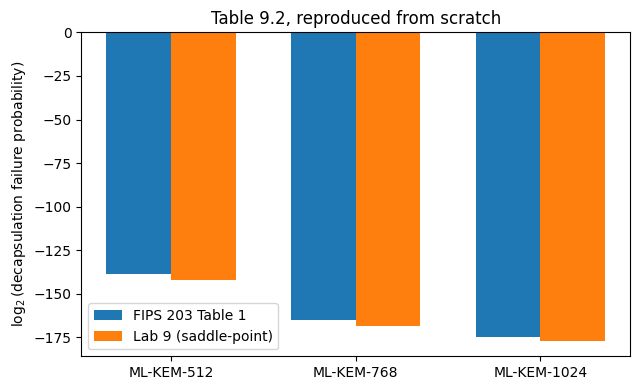

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4))
names = list(PARAMS.keys())
lab_vals = [results[n] for n in names]
pub_vals = [PUBLISHED_LOG2[n] for n in names]
x = np.arange(len(names))
width = 0.35
ax.bar(x - width / 2, pub_vals, width, label="FIPS 203 Table 1")
ax.bar(x + width / 2, lab_vals, width, label="Lab 9 (saddle-point)")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel(r"$\log_2$(decapsulation failure probability)")
ax.set_title("Table 9.2, reproduced from scratch")
ax.legend()
fig.tight_layout()
plt.show()

---

## What to take away

None of this required an external estimator, a borrowed constant, or
the CRYSTALS-Kyber team's own script — every number in Part D's table
comes from $(n,k,q,\eta_1,\eta_2,d_u,d_v)$, the exact CBD and
compression-error distributions those parameters define, and a
large-deviation tail approximation applied honestly. The three-to-four
bit residual against FIPS 203's published figures is exactly the kind
of gap Chapter 9 promised to report rather than hide: "reproduced"
means independently arriving at the same conclusion by a documented,
checkable path, not matching a reference implementation's internal
rounding choices bit for bit. Part C's exact cancellation is the other
half of the same honesty: some claims in this chapter (the
$s^{\top}A^{\top}r$ identity) are exact and were checked exactly;
others (the failure probability) are inherently approximate and were
checked to a stated, honest precision.

In [6]:
# --------------------------------------------------------------------------
# CI smoke test. Runs on every commit; keeps this notebook honest against
# library updates. If this cell fails, the lab is broken -- please open an issue.
# --------------------------------------------------------------------------
def _selftest():
    # Part A: zero failures at a conservative noise level
    rng_ = np.random.default_rng(1)
    pk_, sk_ = regev_keygen(40, 3329, 400, 3.0, rng_)
    fails_ = 0
    for _ in range(200):
        bit_ = int(rng_.integers(0, 2))
        ct_ = regev_encrypt(pk_, 3329, bit_, rng_)
        if regev_decrypt(sk_, ct_, 3329) != bit_:
            fails_ += 1
    assert fails_ == 0

    # Part B: predicted failure rate is monotonically increasing in sigma
    preds_ = [predicted_failure_rate(400, s, 3329) for s in [3, 10, 20, 50, 90]]
    assert all(preds_[i] <= preds_[i + 1] for i in range(len(preds_) - 1))
    assert preds_[0] < 1e-6 and preds_[-1] > 0.4

    # Part C: exact cancellation holds
    n_, q_, k_ = 256, 3329, 2
    rng2_ = np.random.default_rng(2)
    A_ = [[rng2_.integers(0, q_, size=n_) for _ in range(k_)] for _ in range(k_)]
    s_ = [rng2_.integers(0, q_, size=n_) for _ in range(k_)]
    e_ = [rng2_.integers(0, q_, size=n_) for _ in range(k_)]
    r_ = [rng2_.integers(0, q_, size=n_) for _ in range(k_)]
    t_ = [(module_mul(A_[i], s_, q_) + e_[i]) % q_ for i in range(k_)]
    AT_ = [[A_[i][j] for i in range(k_)] for j in range(k_)]
    u_ = [module_mul(AT_[j], r_, q_) for j in range(k_)]
    lhs_ = (module_mul(t_, r_, q_) - module_mul(s_, u_, q_)) % q_
    rhs_ = module_mul(e_, r_, q_)
    assert np.array_equal(lhs_, rhs_)

    # Part D: reproduces the published failure rates to within 5 bits
    for name_, p_ in PARAMS.items():
        got_ = decap_failure_probability(**p_)
        assert abs(got_ - PUBLISHED_LOG2[name_]) < 5.0

    return "all checks passed"

print(_selftest())

all checks passed
